# ***Jacobi Simulation on Karate graph dataset***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import diags
from matplotlib.patches import Patch

In [2]:
"""
Create the Karate Club graph and corresponding matrix
"""
# Load Zachary's Karate Club graph
G = nx.karate_club_graph()

# Create adjacency matrix
A_adj = nx.adjacency_matrix(G).toarray().astype(float)

# Make it strictly diagonally dominant for convergence
A = A_adj.copy()
# print('first time A ',A)
row_sums = np.sum(np.abs(A), axis=1)
# print('row-sum',row_sums)
np.fill_diagonal(A, row_sums + 2.0)  # Ensure strict diagonal dominance
# print('second time',A)
# Get the actual club divisions for coloring
# In the original study, node 0 is the instructor, node 33 is the administrator
club_labels = {}
for i in range(34):
    if i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]:
        club_labels[i] = 'Mr. Hi (Instructor)'
    else:
        club_labels[i] = 'Officer (Administrator)'

In [4]:
print(f"\nGraph Properties:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {np.mean([d for n, d in G.degree()]):.2f}")
print(f"Diameter: {nx.diameter(G)}")
print(f"Communities: 2 (Instructor vs Administrator)")

print(f"\nMatrix Properties:")
print(f"Size: {A.shape[0]} × {A.shape[1]}")
print(f"Strictly diagonally dominant: {np.all(np.diag(A) > np.sum(np.abs(A), axis=1) - np.abs(np.diag(A)))}")
print(f"Condition number: {np.linalg.cond(A):.4f}")


Graph Properties:
Number of nodes: 34
Number of edges: 78
Average degree: 4.59
Diameter: 5
Communities: 2 (Instructor vs Administrator)

Matrix Properties:
Size: 34 × 34
Strictly diagonally dominant: True
Condition number: 13.0199


In [3]:
def jacobi_over_relaxation(A, b, omega, x0, max_iter=1000, tol=1e-10):
    """
    Jacobi over-relaxation method for solving Ax = b
    """
    n = len(b)
    x = x0.copy()
    errors = []

    # Extract diagonal and create off-diagonal matrix
    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D

    for k in range(max_iter):
        x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)

        # Calculate error
        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        # Check convergence
        if error < tol:
            print(f"Converged in {k+1} iterations")
            break

        x = x_new

    return x, errors

In [5]:
# Analyze spectral properties
D = np.diag(np.diag(A))
D_inv = np.diag(1.0 / np.diag(A))
R = A - D
B_J = D_inv @ R

rho_J = np.max(np.sum(np.abs(B_J), axis=1))
print(f"\nSpectral Analysis:")
print(f"Spectral radius of Jacobi matrix (ρ_J): {rho_J:.4f}")
print(f"Theoretical convergence bound: 0 < ω < {2/(1+rho_J):.4f}")


Spectral Analysis:
Spectral radius of Jacobi matrix (ρ_J): 0.9600
Theoretical convergence bound: 0 < ω < 1.0204


In [10]:
# Test different omega values
omega_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]

print(f"\nConvergence Analysis:")
n = A.shape[0]
b = np.random.randn(n) + 10
x0 = np.zeros(n)

for omega in omega_values:
    T_omega = (1 - omega) * np.eye(n) + omega * B_J
    rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))

    # Test actual convergence
    solution, errors = jacobi_over_relaxation(A, b, omega, x0, max_iter=200)
    final_error = errors[-1] if errors else float('inf')
    iterations = len(errors)

    convergence_status = "✓ Converges" if rho_T < 1 else "✗ Diverges"
    print(f"ω = {omega:.1f}: ρ(T_ω) = {rho_T:.4f} | "
          f"Iters = {iterations:3d} | Final error = {final_error:.2e} | {convergence_status}")

# Demonstrate parallel computation aspect
print(f"\nParallel Computation Interpretation:")
print(f"• Each of the 34 nodes represents a processor")
print(f"• Processors only communicate with their neighbors in the graph")
print(f"• Local computation: x_i(k+1) = (1-ω)x_i(k) + (ω/a_ii)(b_i - Σ a_ij x_j(k))")
print(f"• Communication: Each processor sends its value to neighbors")
print(f"• The algorithm exploits the sparse connectivity of the social network")


Convergence Analysis:
Converged in 119 iterations
ω = 0.5: ρ(T_ω) = 0.9405 | Iters = 119 | Final error = 9.47e-11 | ✓ Converges
Converged in 69 iterations
ω = 0.8: ρ(T_ω) = 0.9049 | Iters =  69 | Final error = 9.30e-11 | ✓ Converges
ω = 1.0: ρ(T_ω) = 0.8811 | Iters = 200 | Final error = 7.00e-10 | ✓ Converges
ω = 1.2: ρ(T_ω) = 0.9270 | Iters = 200 | Final error = 5.37e+21 | ✓ Converges
ω = 1.5: ρ(T_ω) = 1.4087 | Iters = 200 | Final error = 8.59e+53 | ✗ Diverges
ω = 1.8: ρ(T_ω) = 1.8905 | Iters = 200 | Final error = 2.37e+77 | ✗ Diverges

Parallel Computation Interpretation:
• Each of the 34 nodes represents a processor
• Processors only communicate with their neighbors in the graph
• Local computation: x_i(k+1) = (1-ω)x_i(k) + (ω/a_ii)(b_i - Σ a_ij x_j(k))
• Communication: Each processor sends its value to neighbors
• The algorithm exploits the sparse connectivity of the social network


Converged in 119 iterations
Converged in 69 iterations
Converged in 216 iterations


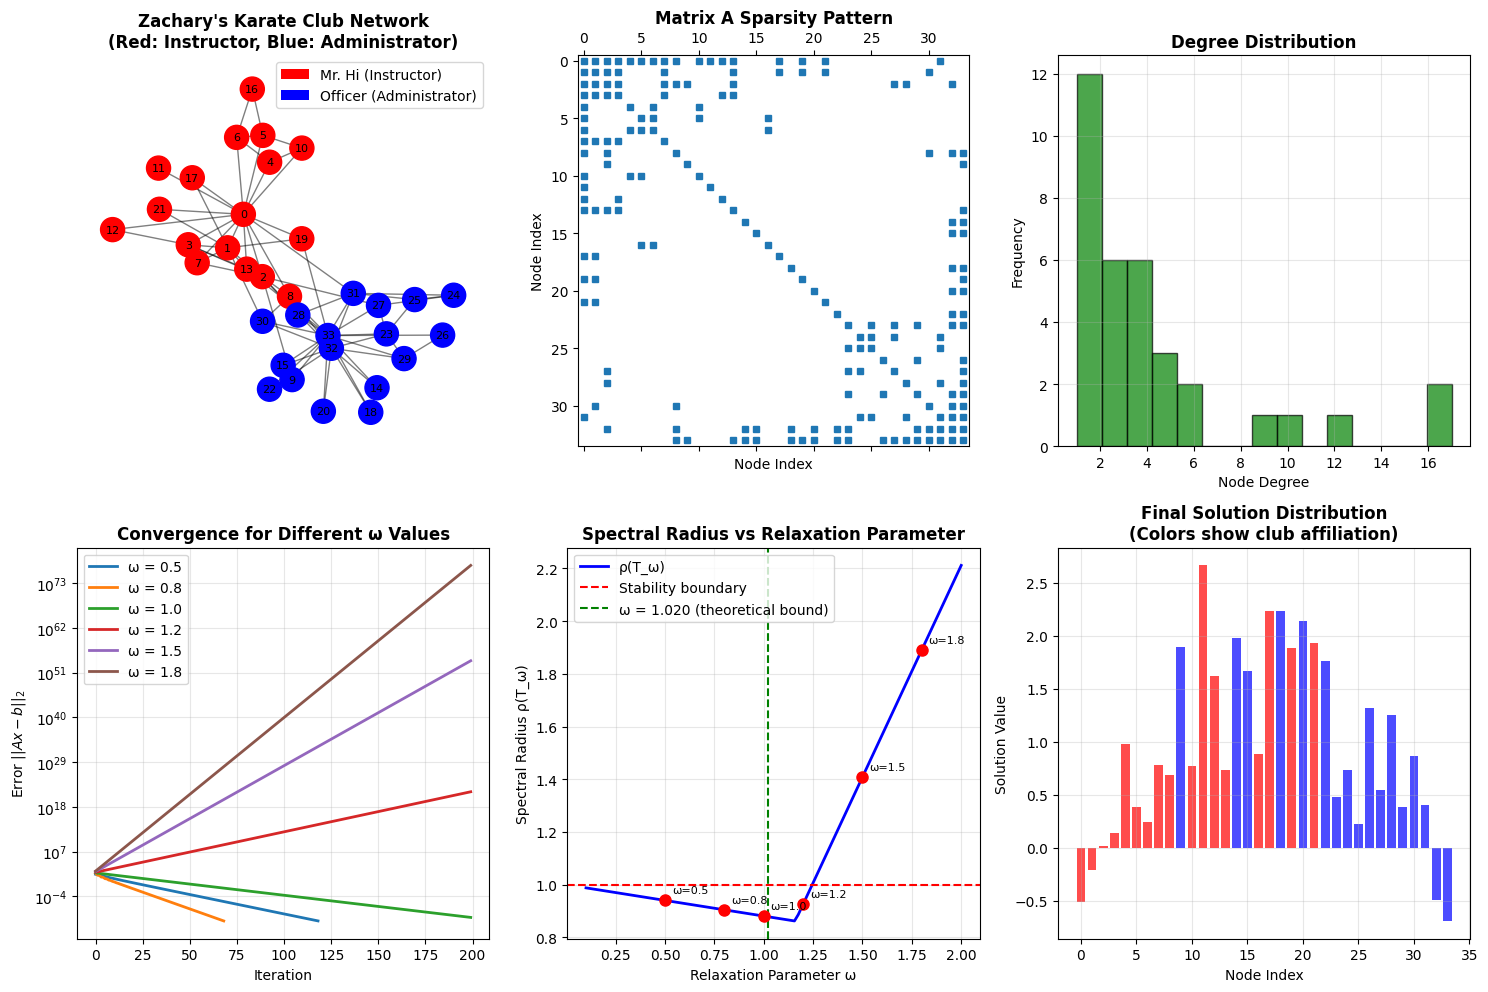

In [9]:

fig = plt.figure(figsize=(15, 10))

# Plot 1: Karate Club graph with community structure
ax1 = plt.subplot(2, 3, 1)
pos = nx.spring_layout(G, seed=42)

# Color nodes by their club affiliation
node_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
                for i in range(len(G))]

nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                      node_size=300, ax=ax1)
nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax1)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1)

# Add legend
legend_elements = [
    Patch(facecolor='red', label='Mr. Hi (Instructor)'),
    Patch(facecolor='blue', label='Officer (Administrator)')
]
ax1.legend(handles=legend_elements, loc='upper right')
ax1.set_title('Zachary\'s Karate Club Network\n(Red: Instructor, Blue: Administrator)',
              fontsize=12, fontweight='bold')
ax1.axis('off')

# Plot 2: Matrix sparsity pattern
ax2 = plt.subplot(2, 3, 2)
ax2.spy(A, markersize=4)
ax2.set_title('Matrix A Sparsity Pattern', fontsize=12, fontweight='bold')
ax2.set_xlabel('Node Index')
ax2.set_ylabel('Node Index')

# Plot 3: Node degrees distribution
ax3 = plt.subplot(2, 3, 3)
degrees = [d for n, d in G.degree()]
ax3.hist(degrees, bins=15, alpha=0.7, color='green', edgecolor='black')
ax3.set_xlabel('Node Degree')
ax3.set_ylabel('Frequency')
ax3.set_title('Degree Distribution', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Convergence for different omega values
ax4 = plt.subplot(2, 3, 4)

# Create a realistic right-hand side (simulating some "influence" distribution)
n = A.shape[0]
b = np.random.randn(n) + 10  # Add constant to ensure positivity
x0 = np.zeros(n)

for omega in omega_values:
    _, errors = jacobi_over_relaxation(A, b, omega, x0, max_iter=200)
    ax4.semilogy(errors, label=f'ω = {omega}', linewidth=2)

ax4.set_xlabel('Iteration')
ax4.set_ylabel('Error $||Ax - b||_2$')
ax4.set_title('Convergence for Different ω Values', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Spectral radius analysis
ax5 = plt.subplot(2, 3, 5)

D = np.diag(np.diag(A))
D_inv = np.diag(1.0 / np.diag(A))
R = A - D
B_J = D_inv @ R

rho_J = np.max(np.sum(np.abs(B_J), axis=1))
omega_range = np.linspace(0.1, 2.0, 100)
spectral_range = []

for omega in omega_range:
    T_omega = (1 - omega) * np.eye(n) + omega * B_J
    rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
    spectral_range.append(rho_T)

ax5.plot(omega_range, spectral_range, 'b-', linewidth=2, label='ρ(T_ω)')
ax5.axhline(y=1, color='r', linestyle='--', label='Stability boundary')
ax5.axvline(x=2/(1+rho_J), color='g', linestyle='--',
            label=f'ω = {2/(1+rho_J):.3f} (theoretical bound)')

# Mark the tested omega values
for omega in omega_values:
    T_omega = (1 - omega) * np.eye(n) + omega * B_J
    rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
    ax5.plot(omega, rho_T, 'ro', markersize=8)
    ax5.annotate(f'ω={omega}', (omega, rho_T),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax5.set_xlabel('Relaxation Parameter ω')
ax5.set_ylabel('Spectral Radius ρ(T_ω)')
ax5.set_title('Spectral Radius vs Relaxation Parameter', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Final solution distribution
ax6 = plt.subplot(2, 3, 6)

# Use optimal omega for final solution
optimal_omega = 1.0
solution, _ = jacobi_over_relaxation(A, b, optimal_omega, x0)

# Color bars by club affiliation
bar_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
              for i in range(len(solution))]

bars = ax6.bar(range(len(solution)), solution, color=bar_colors, alpha=0.7)
ax6.set_xlabel('Node Index')
ax6.set_ylabel('Solution Value')
ax6.set_title('Final Solution Distribution\n(Colors show club affiliation)',
              fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()